# Outlier Detection & Treatment
**IT Number:** IT25102202 · **Name:** Perera K.T. B · **Dataset:** `weatherHistory.csv`

## 1. Why this technique is needed
Sensor-collected weather data can contain both **genuine extreme weather** (a real windstorm, a real cold snap) and **sensor faults** (an impossible reading like 0 millibars of pressure). Treating both the same way — either keeping everything or deleting everything flagged by a statistical rule — would either leave in broken readings or throw away real, informative weather events. So each flagged column is checked individually before deciding whether to cap it or clean it.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../../data/raw/weatherHistory.csv")
num_cols = ["Temperature (C)", "Apparent Temperature (C)", "Humidity",
            "Wind Speed (km/h)", "Wind Bearing (degrees)", "Visibility (km)", "Pressure (millibars)"]

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_counts = ((df[num_cols] < lower) | (df[num_cols] > upper)).sum()
print(outlier_counts)

Temperature (C)               44
Apparent Temperature (C)      22
Humidity                      46
Wind Speed (km/h)           3028
Wind Bearing (degrees)         0
Visibility (km)                0
Pressure (millibars)        4400
dtype: int64


In [2]:
print("Pressure = 0 mb readings:", (df["Pressure (millibars)"] == 0).sum())
print(df.loc[df["Pressure (millibars)"] == 0, ["Summary", "Temperature (C)", "Pressure (millibars)"]].head())
print()
print("Pressure describe (excluding 0s):")
print(df.loc[df["Pressure (millibars)"] > 0, "Pressure (millibars)"].describe())

Pressure = 0 mb readings: 1288
            Summary  Temperature (C)  Pressure (millibars)
858   Partly Cloudy        22.477778                   0.0
874   Partly Cloudy        21.061111                   0.0
924           Clear        28.838889                   0.0
945           Clear        24.950000                   0.0
1074  Partly Cloudy        23.811111                   0.0

Pressure describe (excluding 0s):
count    95165.000000
mean      1016.814140
std          7.778356
min        973.780000
25%       1012.120000
50%       1016.550000
75%       1021.160000
max       1046.380000
Name: Pressure (millibars), dtype: float64


**Pressure** has 1,288 rows reading exactly `0.0` millibars — sea-level atmospheric pressure never actually drops anywhere near zero, so these are **sensor faults**, not real weather. They're treated as missing and replaced with the column median. **Wind Speed** has 3,028 IQR-flagged high values, but wind gusts up to ~64 km/h are meteorologically realistic (storm-force winds), so instead of deleting these rows outright, they're **capped (winsorized)** at the IQR upper bound — this keeps every row in the dataset while still pulling in the extreme tail that could otherwise skew scaling and modelling later in the pipeline.

In [3]:
# Pressure = 0 -> sensor fault, not a real reading -> treat as missing, fill with median of valid readings
valid_pressure_median = df.loc[df["Pressure (millibars)"] > 0, "Pressure (millibars)"].median()
df["Pressure (millibars)"] = df["Pressure (millibars)"].replace(0, valid_pressure_median)
print("Pressure = 0 remaining:", (df["Pressure (millibars)"] == 0).sum())
print("Filled with median:", valid_pressure_median)

Pressure = 0 remaining: 0
Filled with median: 1016.55


In [4]:
# Winsorize (cap) the remaining flagged columns instead of dropping rows, to preserve real extreme-weather events
cap_cols = ["Temperature (C)", "Apparent Temperature (C)", "Humidity", "Wind Speed (km/h)"]

before_stats = df[cap_cols].agg(["min", "max"])

for col in cap_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    df[col] = df[col].clip(lower=lo, upper=hi)

after_stats = df[cap_cols].agg(["min", "max"])
print("BEFORE capping:")
print(before_stats)
print("\nAFTER capping:")
print(after_stats)
print("\nRows remaining:", len(df), "(no rows dropped)")

BEFORE capping:
     Temperature (C)  Apparent Temperature (C)  Humidity  Wind Speed (km/h)
min       -21.822222                -27.716667       0.0             0.0000
max        39.905556                 39.344444       1.0            63.8526

AFTER capping:
     Temperature (C)  Apparent Temperature (C)  Humidity  Wind Speed (km/h)
min       -16.536111                -22.480556     0.165             0.0000
max        39.905556                 39.344444     1.000            26.5972

Rows remaining: 96453 (no rows dropped)


In [5]:
import os
os.makedirs("../results/outputs", exist_ok=True)
df.to_csv("../results/outputs/member4_outliers_treated.csv", index=False)
print("Saved. Final shape:", df.shape)

Saved. Final shape: (96453, 12)


## 2. EDA Visualization

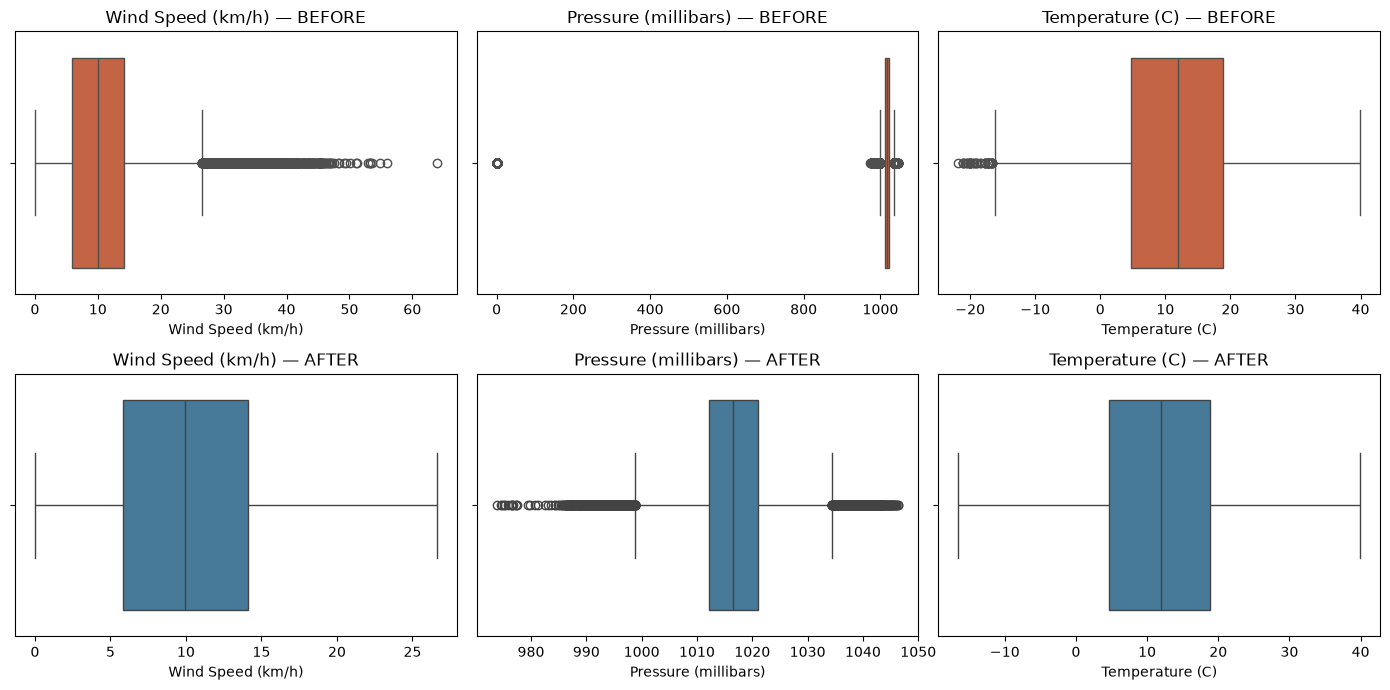

In [ ]:
raw = pd.read_csv("../data/raw/weatherHistory.csv")
box_cols = ["Wind Speed (km/h)", "Pressure (millibars)", "Temperature (C)"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for i, col in enumerate(box_cols):
    sns.boxplot(x=raw[col], ax=axes[0, i], color="#D85A30")
    axes[0, i].set_title(f"{col} — BEFORE")
for i, col in enumerate(box_cols):
    sns.boxplot(x=df[col], ax=axes[1, i], color="#3A7CA5")
    axes[1, i].set_title(f"{col} — AFTER")

plt.tight_layout()

import os
os.makedirs("../results/eda_visualizations", exist_ok=True)
plt.savefig("../results/eda_visualizations/member4_outlier_treatment.png", dpi=110)
plt.show()

**Interpretation:** the Pressure boxplot's lower tail no longer touches 0 once the sensor-fault readings are fixed — the axis now runs across a physically plausible 974–1046 mb instead of stretching to zero. Some points still sit outside the IQR whiskers on both ends, but those are genuine high/low-pressure weather systems (973–998 mb and 1035–1046 mb), left untouched deliberately rather than capped away. Wind Speed keeps its upper whisker but no longer has values racing off the top of the chart — the genuine high-wind hours are still represented, just no longer able to dominate the scale of the column the way an unbounded value would.